# Masterclass de Clustering (con Temporalidad) — Online Retail II
**Autor:** Josef Rodriguez  
**Dataset (repo):** `data/online_retail_II.xlsx` (2 sheets)  
**RAW URL (fallback):** `https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/online_retail_II.xlsx`

Este notebook esta pensado para correr **desde tu repo**. Si el Excel no existe localmente, lo descarga desde GitHub RAW.

## Flujo de la masterclass
1) Diccionario de datos (formal)  
2) Limpieza y reglas de calidad  
3) Feature engineering **cliente–mes** con **ventana movil**  
4) Modelos: K-Means, Jerarquico (Ward), DBSCAN  
5) Seleccion de hiperparametros (K, eps)  
6) Evaluacion (Silhouette, Davies-Bouldin, Calinski-Harabasz)  
7) Visualizacion (PCA 2D)  
8) Estabilidad temporal y migracion de clusters  
9) Persistencia para produccion (scaler + modelo + features)

In [1]:
# ===============================
# 0) Imports y configuracion
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

import joblib
import urllib.request

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

print("OK - imports")

OK - imports


## 1) Diccionario de Datos (resumen formal)
**Variables raw:**
- InvoiceNo (string): factura; inicia con 'C' = cancelacion
- StockCode (string): codigo producto
- Description (string): descripcion
- Quantity (int): cantidad; negativos = devoluciones
- UnitPrice (float): precio unitario; filtrar <= 0
- InvoiceDate (datetime): timestamp (clave)
- CustomerID (string): id cliente; puede ser nulo
- Country (string): pais

**Features para clustering (por cliente y tiempo):**
- Monetary: \(\sum Quantity \cdot UnitPrice\)
- Frequency: #InvoiceNo distintos en ventana
- Recency: dias desde ultima compra al cierre del mes
- Ticket promedio: Monetary / Frequency
- Diversidad: #StockCode distintos

## 2) Carga desde tu repo (Excel con 2 sheets)
Este dataset tiene 2 hojas:
- `Year 2009-2010`
- `Year 2010-2011`

El loader:
1) Lee el Excel local `data/online_retail_II.xlsx`
2) Si no existe, lo descarga desde RAW de GitHub
3) Concatena ambas hojas y estandariza tipos

In [2]:
# ===============================
# 2) Loader robusto (local -> descarga -> leer 2 sheets)
# ===============================
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

xlsx_path = DATA_DIR / "online_retail_II.xlsx"
csv_path  = DATA_DIR / "online_retail_II_full.csv"

RAW_URL = "https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/online_retail_II.xlsx"

def ensure_xlsx_local(xlsx_path: Path, raw_url: str) -> Path:
    if xlsx_path.exists() and xlsx_path.stat().st_size > 0:
        return xlsx_path
    print("No se encontro Excel local. Descargando desde GitHub RAW...")
    urllib.request.urlretrieve(raw_url, xlsx_path.as_posix())
    print("Descarga OK:", xlsx_path, "| size:", xlsx_path.stat().st_size/1024/1024, "MB")
    return xlsx_path

def load_online_retail_from_xlsx(xlsx_path: Path) -> pd.DataFrame:
    # engine openpyxl suele ser necesario
    df_2009 = pd.read_excel(xlsx_path, sheet_name="Year 2009-2010", engine="openpyxl")
    df_2010 = pd.read_excel(xlsx_path, sheet_name="Year 2010-2011", engine="openpyxl")
    df = pd.concat([df_2009, df_2010], ignore_index=True)
    return df

def load_online_retail(csv_path: Path, xlsx_path: Path, raw_url: str) -> pd.DataFrame:
    if csv_path.exists():
        print("Cargando CSV:", csv_path)
        return pd.read_csv(csv_path)
    xlsx_path = ensure_xlsx_local(xlsx_path, raw_url)
    print("Cargando XLSX:", xlsx_path)
    return load_online_retail_from_xlsx(xlsx_path)

df_raw = load_online_retail(csv_path, xlsx_path, RAW_URL)
print("Shape raw:", df_raw.shape)
df_raw.head()

Cargando XLSX: data/online_retail_II.xlsx
Shape raw: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# ==========================================
# Normalizacion de nombres de columnas
# ==========================================

print("Columnas originales:")
print(df_raw.columns)

# 1) Quitar espacios al inicio y final
df_raw.columns = df_raw.columns.str.strip()

# 2) Reemplazar espacios internos (ej: 'Customer ID' -> 'CustomerID')
df_raw.columns = df_raw.columns.str.replace(" ", "", regex=False)

# 3) (Opcional) Renombrado explicito por claridad
df_raw = df_raw.rename(columns={
    "CustomerID": "CustomerID"  # ya sin espacio, por seguridad
})

print("\nColumnas despues de normalizacion:")
print(df_raw.columns)

Columnas originales:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country'], dtype='str')

Columnas despues de normalizacion:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country'], dtype='str')


In [6]:
# ===============================
# 2.1) Estandarizar tipos
# ===============================
df = df_raw.copy()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# CustomerID puede venir float en Excel -> string
df["CustomerID"] = df["CustomerID"].astype("string")

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   CustomerID   824364 non-null   string        
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(1), string(1)
memory usage: 65.1+ MB


## 3) Limpieza (reglas de calidad)
Reglas aplicadas (modo didactico):
1) Eliminar `CustomerID` nulo
2) Eliminar `InvoiceDate` nulo
3) Filtrar `UnitPrice > 0`
4) Filtrar `Quantity > 0` (solo compras; devoluciones se excluyen en esta clase)
5) Crear `LineAmount = Quantity * UnitPrice`

In [9]:
before = len(df)

df = df.dropna(subset=["CustomerID","InvoiceDate"])
df = df[df["Price"] > 0]
df = df[df["Quantity"] > 0]

df["LineAmount"] = df["Quantity"] * df["Price"]

after = len(df)
print(f"Filas antes: {before:,} | despues: {after:,} | removidas: {before-after:,} ({(before-after)/max(before,1):.2%})")
df.head()

Filas antes: 805,549 | despues: 805,549 | removidas: 0 (0.00%)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,LineAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


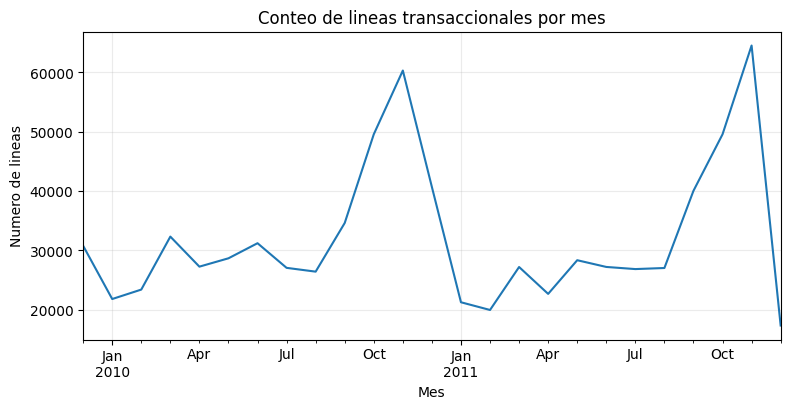

In [10]:
# Distribucion temporal (conteo de lineas por mes)
plt.figure(figsize=(9,4))
df["InvoiceDate"].dt.to_period("M").value_counts().sort_index().plot(kind="line")
plt.title("Conteo de lineas transaccionales por mes")
plt.xlabel("Mes")
plt.ylabel("Numero de lineas")
plt.grid(True, alpha=0.25)
plt.show()

## 4) Feature Engineering Temporal: Cliente–Mes con Ventana Movil


Sea:

$$
t
$$
Mes de referencia.

$$
t_{\text{end}}
$$
Ultimo dia del mes \( t \).

$$
W
$$
Ventana temporal (por ejemplo, \( W = 90 \) dias).

Definimos el intervalo de observacion:

$$
\mathcal{T}_{t,W}
=
\left(
t_{\text{end}} - W,\; t_{\text{end}}
\right]
$$ el intervalo de observacion  

La unidad de analisis es **Cliente–Mes**.

---

###  Monetary (Valor Monetario)

$$
M_{i,t,W}
=
\sum_{j \in \mathcal{T}_{t,W}}
\left(
Quantity_{i,j} \cdot Price_{i,j}
\right)
$$

Representa el gasto total del cliente \( i \) en la ventana \( W \).

---

###  Frequency (Frecuencia de Compra)

$$
F_{i,t,W}
=
\left|
\left\{
InvoiceNo_{i,j}
\; : \;
j \in \mathcal{T}_{t,W}
\right\}
\right|
$$

Es el numero de facturas distintas del cliente \( i \) en la ventana.

---

###  Recency (Recencia)

$$
R_{i,t}
=
\left(
t_{\text{end}}
-
\max_{j \in \mathcal{T}_{t,W}}
\left( InvoiceDate_{i,j} \right)
\right)_{\text{dias}}
$$

Mide los dias transcurridos desde la ultima compra hasta el cierre del mes \( t \).

---

###  Ticket Promedio

$$
Ticket_{i,t,W}
=
\frac{M_{i,t,W}}
{\max\left(F_{i,t,W},\,1\right)}
$$

Se utiliza el maximo con 1 para evitar division por cero.

---

###  Diversidad de Productos

$$
D_{i,t,W}
=
\left|
\left\{
StockCode_{i,j}
\; : \;
j \in \mathcal{T}_{t,W}
\right\}
\right|
$$

Numero de productos distintos adquiridos en la ventana.

---

###  Interpretacion Conceptual

- \( M \) captura el **valor economico**
- \( F \) captura la **intensidad de compra**
- \( R \) captura la **actividad reciente**
- \( Ticket \) captura el **nivel promedio de gasto**
- \( D \) captura la **variedad de consumo**

In [12]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'LineAmount', 'month'], dtype='str')

In [14]:
WINDOW_DAYS = 90

df["month"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
months = pd.Series(df["month"].unique()).sort_values().to_list()
print("Meses:", len(months), "|", min(months), "->", max(months))

def build_customer_month_features(df_in: pd.DataFrame, months, window_days: int) -> pd.DataFrame:
    out = []
    for m in months:
        month_start = pd.Timestamp(m)
        month_end = month_start + pd.offsets.MonthEnd(0)
        window_start = month_end - pd.Timedelta(days=window_days)

        w = df_in[(df_in["InvoiceDate"] > window_start) & (df_in["InvoiceDate"] <= month_end)].copy()
        if w.empty:
            continue

        g = w.groupby("CustomerID").agg(
            monetary=("LineAmount","sum"),
            freq_invoices=("Invoice", pd.Series.nunique),
            qty_total=("Quantity","sum"),
            unique_products=("StockCode", pd.Series.nunique),
            last_purchase=("InvoiceDate","max"),
            country=("Country", lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0]),
        ).reset_index()

        g["month"] = month_start
        g["recency_days"] = (month_end - g["last_purchase"]).dt.days.clip(lower=0)
        g["ticket_avg"] = g["monetary"] / np.maximum(g["freq_invoices"], 1)

        out.append(g.drop(columns=["last_purchase"]))

    return pd.concat(out, ignore_index=True)

cm = build_customer_month_features(df, months, WINDOW_DAYS)
print("Cliente-mes:", cm.shape)
cm.head()

Meses: 25 | 2009-12-01 00:00:00 -> 2011-12-01 00:00:00
Cliente-mes: (51117, 9)


,CustomerID,monetary,freq_invoices,qty_total,unique_products,country,month,recency_days,ticket_avg
0,12346.0,113.50,5,26,2,United Kingdom,2009-12-01,12,22.700
1,12358.0,1429.83,1,309,17,Austria,2009-12-01,22,1429.830
2,12359.0,838.89,2,609,34,Cyprus,2009-12-01,14,419.445
3,12362.0,130.00,1,1,1,Belgium,2009-12-01,29,130.000
4,12417.0,317.60,2,152,19,Belgium,2009-12-01,20,158.800


In [15]:
# Chequeo rapido de features (raw)
feat_raw = ["monetary","freq_invoices","recency_days","ticket_avg","unique_products","qty_total"]
cm[feat_raw].describe().T

,count,mean,std,min,25%,50%,75%,max
monetary,51117.0,985.001294,3364.322760,0.85,239.620,430.28,871.60,168469.6
freq_invoices,51117.0,2.058200,2.630118,1.00,1.000,1.00,2.00,84.0
recency_days,51117.0,34.896414,25.083610,0.00,13.000,30.00,54.00,89.0
ticket_avg,51117.0,420.302141,1089.482399,0.85,183.955,306.33,463.12,168469.6
unique_products,51117.0,36.334233,45.723738,1.00,12.000,24.00,45.00,1164.0
qty_total,51117.0,596.446564,2619.848441,1.00,119.000,248.00,508.00,220506.0


## 5) Preparacion (log + escalamiento)
En retail (y banca) hay colas pesadas. Usamos `log1p` para estabilizar, y luego escalamos:

\[
z = \frac{x - \mu}{\sigma}
\]

In [16]:
cm2 = cm.copy()

for c in ["monetary","ticket_avg","qty_total","unique_products","freq_invoices"]:
    cm2[f"log_{c}"] = np.log1p(cm2[c])

feat_model = ["log_monetary","log_ticket_avg","log_qty_total","log_unique_products","log_freq_invoices","recency_days"]

X = cm2[feat_model].replace([np.inf, -np.inf], np.nan).dropna()
cm2 = cm2.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X:", X.shape, "| X_scaled:", X_scaled.shape)

X: (51117, 6) | X_scaled: (51117, 6)


## 6) K-Means: elegir K + entrenar
Objetivo de K-Means:

$$
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \left\| x_i - \mu_k \right\|^2
$$

Metricas:
- Silhouette (max)
- Davies-Bouldin (min)
- Calinski-Harabasz (max)

In [17]:
def kmeans_sweep(X_in, k_min=2, k_max=12, random_state=RANDOM_STATE):
    rows = []
    for k in range(k_min, k_max+1):
        km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = km.fit_predict(X_in)
        rows.append({
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X_in, labels),
            "davies_bouldin": davies_bouldin_score(X_in, labels),
            "calinski_harabasz": calinski_harabasz_score(X_in, labels),
        })
    return pd.DataFrame(rows)

sweep = kmeans_sweep(X_scaled, 2, 12)
sweep

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,197633.973297,0.307622,1.206699,28208.993352
1,3,160276.194526,0.243258,1.301857,23348.549177
2,4,138524.583062,0.231100,1.294416,20684.858809
3,5,122481.829865,0.227027,1.259472,19219.001835
4,6,109590.494641,0.230557,1.253895,18385.883767
5,7,102425.219912,0.220375,1.258264,16989.054739
6,8,95928.868689,0.207045,1.253731,16042.365323
7,9,89814.365235,0.209188,1.240714,15427.262219
8,10,85553.279527,0.206242,1.262500,14678.667296
9,11,81569.758222,0.209317,1.221119,14105.264132


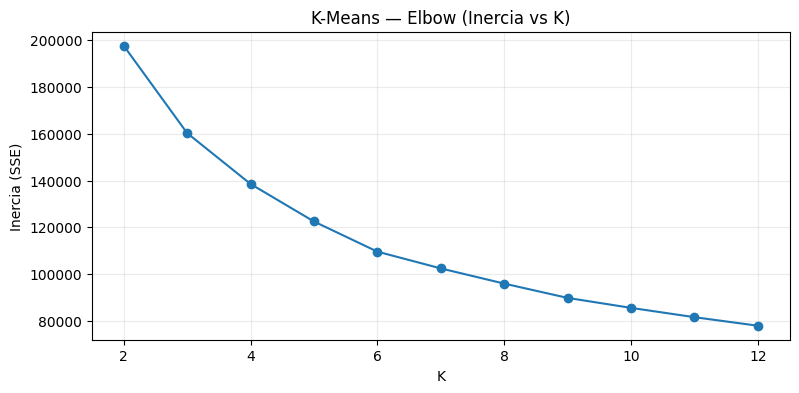

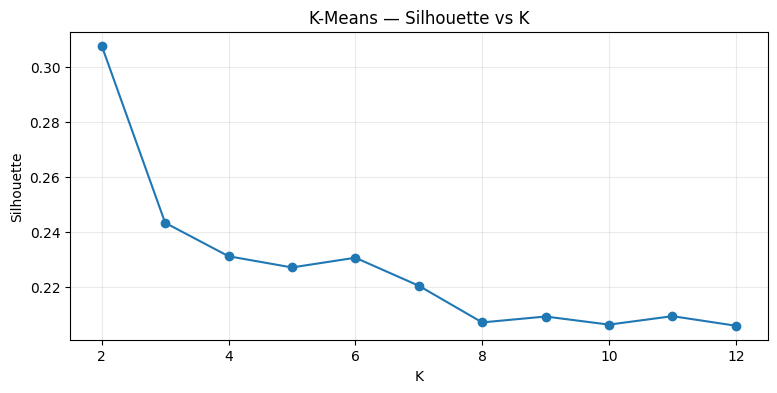

In [18]:
plt.figure(figsize=(9,4))
plt.plot(sweep["k"], sweep["inertia"], marker="o")
plt.title("K-Means — Elbow (Inercia vs K)")
plt.xlabel("K")
plt.ylabel("Inercia (SSE)")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(9,4))
plt.plot(sweep["k"], sweep["silhouette"], marker="o")
plt.title("K-Means — Silhouette vs K")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.grid(True, alpha=0.25)
plt.show()

In [19]:
K_FINAL = int(sweep.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("K_FINAL sugerido:", K_FINAL)

kmeans = KMeans(n_clusters=K_FINAL, n_init=30, random_state=RANDOM_STATE)
labels_km = kmeans.fit_predict(X_scaled)

cm2["cluster_kmeans"] = labels_km

sil = silhouette_score(X_scaled, labels_km)
dbi = davies_bouldin_score(X_scaled, labels_km)
chi = calinski_harabasz_score(X_scaled, labels_km)
print(f"K-Means | silhouette={sil:.4f} | davies_bouldin={dbi:.4f} | calinski_harabasz={chi:.2f}")

cm2["cluster_kmeans"].value_counts().sort_index()

K_FINAL sugerido: 2
K-Means | silhouette=0.3076 | davies_bouldin=1.2067 | calinski_harabasz=28208.99


cluster_kmeans
0    22173
1    28944
Name: count, dtype: int64

## 7) Visualizacion PCA 2D

Explained variance ratio: [0.5955 0.1878] | Sum: 0.7832


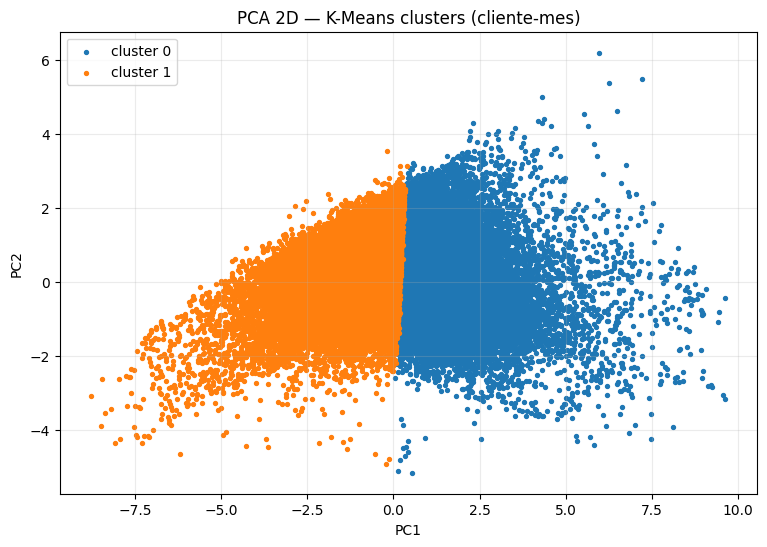

In [20]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(4), "| Sum:", pca.explained_variance_ratio_.sum().round(4))

plt.figure(figsize=(9,6))
for c in sorted(cm2["cluster_kmeans"].unique()):
    m = cm2["cluster_kmeans"] == c
    plt.scatter(X_2d[m,0], X_2d[m,1], s=8, label=f"cluster {c}")
plt.title("PCA 2D — K-Means clusters (cliente-mes)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

## 8) Perfilado (segmentos accionables)

In [21]:
profile_cols = ["monetary","freq_invoices","recency_days","ticket_avg","unique_products","qty_total"]
prof = cm2.groupby("cluster_kmeans")[profile_cols].agg(["count","mean","median"])
prof.columns = [f"{a}_{b}" for a,b in prof.columns]
prof.sort_index()

,monetary_count,monetary_mean,monetary_median,freq_invoices_count,freq_invoices_mean,freq_invoices_median,recency_days_count,recency_days_mean,recency_days_median,ticket_avg_count,ticket_avg_mean,ticket_avg_median,unique_products_count,unique_products_mean,unique_products_median,qty_total_count,qty_total_mean,qty_total_median
cluster_kmeans,,,,,,,,,,,,,,,,,,
0,22173,1901.572810,970.60,22173,3.167952,2.0,22173,23.733460,19.0,22173,644.075829,448.12,22173,60.613584,46.0,22173,1165.789654,559.0
1,28944,282.847473,268.27,28944,1.208057,1.0,28944,43.447968,43.0,28944,248.876838,219.40,28944,17.734660,15.0,28944,160.292461,134.0


## 9) Jerarquico (Ward)

In [22]:
agg = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
labels_agg = agg.fit_predict(X_scaled)
cm2["cluster_agglo"] = labels_agg

sil = silhouette_score(X_scaled, labels_agg)
dbi = davies_bouldin_score(X_scaled, labels_agg)
chi = calinski_harabasz_score(X_scaled, labels_agg)
print(f"Agglo(Ward) | silhouette={sil:.4f} | davies_bouldin={dbi:.4f} | calinski_harabasz={chi:.2f}")

Agglo(Ward) | silhouette=0.3071 | davies_bouldin=1.1014 | calinski_harabasz=18787.34


## 10) DBSCAN (densidad + ruido) con k-distance plot

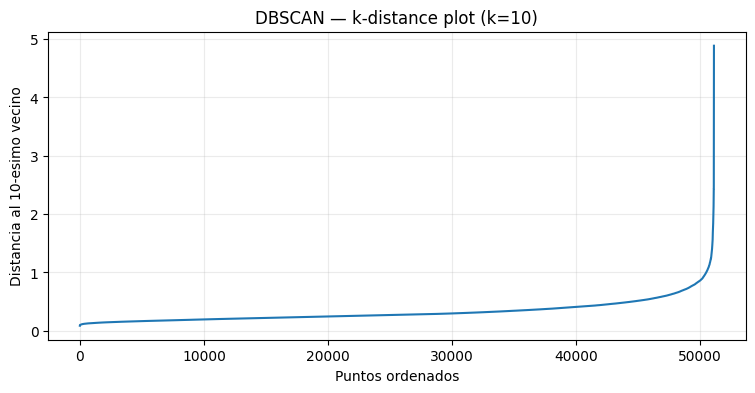

eps sugerido (p95): 0.6890228821852424


cluster_dbscan
-1      1240
 0     29214
 1     10674
 2      9829
 3        19
 4        28
 5        15
 6        20
 7        13
 8        36
 9         7
 10       12
 11       10
Name: count, dtype: int64

In [23]:
min_samples = 10
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(9,4))
plt.plot(k_dist)
plt.title(f"DBSCAN — k-distance plot (k={min_samples})")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {min_samples}-esimo vecino")
plt.grid(True, alpha=0.25)
plt.show()

eps = float(np.percentile(k_dist, 95))
print("eps sugerido (p95):", eps)

db = DBSCAN(eps=eps, min_samples=min_samples)
labels_db = db.fit_predict(X_scaled)
cm2["cluster_dbscan"] = labels_db

cm2["cluster_dbscan"].value_counts().sort_index()

## 11) Temporalidad: estabilidad y migracion
1) Shares por mes  
2) Matriz de transicion cliente a cliente (t -> t+1)

In [25]:
shares = (
    cm2
    .groupby(["month", "cluster_kmeans"])
    .size()
    .reset_index(name="count")
)

# Normalizar dentro de cada mes
shares["share"] = (
    shares
    .groupby("month")["count"]
    .transform(lambda x: x / x.sum())
)

# Pivot
pivot = (
    shares
    .pivot(index="month", columns="cluster_kmeans", values="share")
    .fillna(0)
    .sort_index()
)

pivot.head()

cluster_kmeans,0,1
month,,
2009-12-01,0.348691,0.651309
2010-01-01,0.395579,0.604421
2010-02-01,0.402001,0.597999
2010-03-01,0.417743,0.582257
2010-04-01,0.419272,0.580728


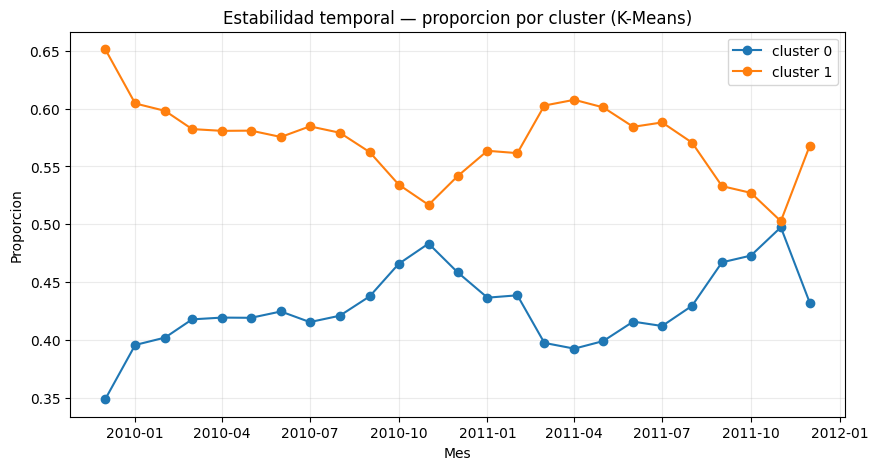

In [26]:
plt.figure(figsize=(10,5))
for c in pivot.columns:
    plt.plot(pivot.index, pivot[c], marker="o", label=f"cluster {c}")
plt.title("Estabilidad temporal — proporcion por cluster (K-Means)")
plt.xlabel("Mes")
plt.ylabel("Proporcion")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

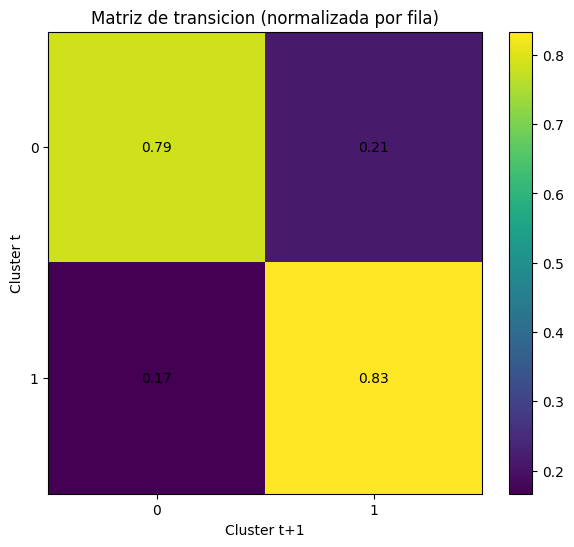

cluster_next,0,1
cluster_kmeans,,
0,0.785849,0.214151
1,0.166721,0.833279


In [27]:
cm_sorted = cm2.sort_values(["CustomerID","month"]).copy()
cm_sorted["cluster_next"] = cm_sorted.groupby("CustomerID")["cluster_kmeans"].shift(-1)

trans = cm_sorted.dropna(subset=["cluster_next"]).copy()
trans["cluster_next"] = trans["cluster_next"].astype(int)

mat = pd.crosstab(trans["cluster_kmeans"], trans["cluster_next"], normalize="index")

plt.figure(figsize=(7,6))
plt.imshow(mat.values, aspect="auto")
plt.title("Matriz de transicion (normalizada por fila)")
plt.xlabel("Cluster t+1")
plt.ylabel("Cluster t")
plt.xticks(range(mat.shape[1]), mat.columns)
plt.yticks(range(mat.shape[0]), mat.index)
plt.colorbar()
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        plt.text(j, i, f"{mat.values[i,j]:.2f}", ha="center", va="center")
plt.show()

mat

## 12) Guardar artefactos (produccion)

In [28]:
ART_DIR = Path("artifacts_clustering_retail")
ART_DIR.mkdir(exist_ok=True)

joblib.dump(scaler, ART_DIR / "scaler.joblib")
joblib.dump(kmeans, ART_DIR / "kmeans.joblib")
pd.Series(feat_model).to_csv(ART_DIR / "features.csv", index=False, header=False)

print("Artefactos guardados en:", ART_DIR.resolve())

Artefactos guardados en: /Users/josefrodriguez/repos/ML_course/ML-course/artifacts_clustering_retail


# Versión Industria Financiera — Segmentación, Estabilidad y Transiciones

Este bloque convierte el ejercicio de clustering en un enfoque **apto para industria financiera** (riesgo/marketing/CRM), agregando:

- **Gobernanza del modelo de segmentación** (reproducibilidad, trazabilidad, control de cambios)
- **Estabilidad temporal** (¿los clusters son consistentes mes a mes?)
- **Transiciones** (¿cómo migran los clientes entre segmentos?)
- **Monitoreo** (drift de distribución y drift de centroides)

> Nota: este notebook segmenta por comportamiento transaccional (tipo RFM extendido).  
> En banca, el “valor” puede ser *ingresos, margen, uso de productos, riesgo, mora*, etc. La mecánica es la misma: **features → escalado → clustering → perfilado → monitoreo**.


In [29]:
# ============================
# 12) Preparación para análisis temporal (z-features)
# ============================
# Guardamos las features escaladas (z_*) en el mismo cm2 para:
# - Estabilidad temporal (ARI/NMI)
# - Drift de centroides por mes (distancia a centros globales KMeans)
# - Perfilado robusto por mes y por cluster

z_cols = [f"z_{c}" for c in feat_model]
z_df = pd.DataFrame(X_scaled, columns=z_cols, index=cm2.index)

for c in z_cols:
    cm2[c] = z_df[c].values

cm2[["month","CustomerID","cluster_kmeans"] + z_cols].head()


,month,CustomerID,cluster_kmeans,z_log_monetary,z_log_ticket_avg,z_log_qty_total,z_log_unique_products,z_log_freq_invoices,z_recency_days
0,2009-12-01,12346.0,1,-1.328705,-3.203767,-1.819593,-2.095859,1.855089,-0.912813
1,2009-12-01,12358.0,0,1.059173,1.989804,0.193312,-0.279140,-0.673865,-0.514142
2,2009-12-01,12359.0,0,0.555451,0.438653,0.751548,0.395099,0.259497,-0.833079
3,2009-12-01,12362.0,1,-1.201416,-1.038302,-3.966064,-2.506972,-0.673865,-0.235073
4,2009-12-01,12417.0,1,-0.361085,-0.786604,-0.389046,-0.172312,0.259497,-0.593876


## 12.1 Estabilidad temporal de clusters (ARI / NMI)

Sea:

$$
\mathcal{C}_t = \{ i : \text{cliente } i \text{ aparece en el mes } t \}
$$

Para meses consecutivos \(t\) y \(t+1\), definimos el conjunto común:

$$
\mathcal{I}_{t,t+1} = \mathcal{C}_t \cap \mathcal{C}_{t+1}
$$

Sea la función de asignación de clusters:

$$
c_t(i) \in \{1,\dots,K\}
$$

donde \(c_t(i)\) es el cluster asignado al cliente \(i\) en el mes \(t\).

Comparamos las particiones:

$$
\mathbf{c}_t = \{c_t(i) : i \in \mathcal{I}_{t,t+1}\}
$$

$$
\mathbf{c}_{t+1} = \{c_{t+1}(i) : i \in \mathcal{I}_{t,t+1}\}
$$

---

###  Adjusted Rand Index (ARI)

Sea:

- \(a\) = número de pares de clientes que están en el mismo cluster en ambos meses  
- \(b\) = número de pares en distintos clusters en ambos meses  

El índice Rand es:

$$
RI = \frac{a + b}{\binom{n}{2}}
$$

donde \(n = |\mathcal{I}_{t,t+1}|\).

El **ARI** corrige por azar:

$$
ARI =
\frac{
RI - \mathbb{E}[RI]
}{
\max(RI) - \mathbb{E}[RI]
}
$$

Rango:

$$
ARI \in [-1, 1]
$$

Interpretación práctica:

- \(ARI \approx 1\) → particiones casi idénticas  
- \(ARI \approx 0\) → asignación comparable al azar  
- \(ARI < 0\) → peor que azar  

---

###  Normalized Mutual Information (NMI)

Sea \(H(C_t)\) la entropía de la partición en el mes \(t\):

$$
H(C_t) = - \sum_{k=1}^{K} P_t(k)\log P_t(k)
$$

donde \(P_t(k)\) es la proporción de clientes en el cluster \(k\).

La información mutua entre ambas particiones es:

$$
I(C_t, C_{t+1}) =
\sum_{k,l}
P_{t,t+1}(k,l)
\log
\frac{
P_{t,t+1}(k,l)
}{
P_t(k)P_{t+1}(l)
}
$$

La NMI es:

$$
NMI =
\frac{
2 I(C_t, C_{t+1})
}{
H(C_t) + H(C_{t+1})
}
$$

Rango:

$$
NMI \in [0,1]
$$

Interpretación:

- \(NMI = 1\) → segmentación idéntica  
- \(NMI = 0\) → independencia total  

---

## Interpretación Operativa (Industria)

- ARI/NMI altos → segmentos estructurales estables  
- ARI/NMI medios → clientes con movilidad natural  
- ARI/NMI bajos → posible:
  - ventana \(W\) muy corta  
  - estacionalidad fuerte  
  - clusters mal separados  
  - features con alto ruido  

En banca/CRM, estabilidad moderada-alta es deseable para
evitar cambios arbitrarios en campañas o pricing.


In [30]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

def temporal_stability(df_labels: pd.DataFrame, month_col="month", id_col="CustomerID", label_col="cluster_kmeans"):
    months_sorted = sorted(df_labels[month_col].unique())
    rows = []
    for i in range(len(months_sorted)-1):
        m0, m1 = months_sorted[i], months_sorted[i+1]
        a = df_labels[df_labels[month_col]==m0][[id_col,label_col]].rename(columns={label_col:"c0"})
        b = df_labels[df_labels[month_col]==m1][[id_col,label_col]].rename(columns={label_col:"c1"})
        j = a.merge(b, on=id_col, how="inner")
        if len(j) < 50:  # umbral mínimo razonable
            rows.append({"month_t": m0, "month_t1": m1, "n_common": len(j), "ARI": np.nan, "NMI": np.nan})
            continue
        ari = adjusted_rand_score(j["c0"], j["c1"])
        nmi = normalized_mutual_info_score(j["c0"], j["c1"])
        rows.append({"month_t": m0, "month_t1": m1, "n_common": len(j), "ARI": ari, "NMI": nmi})
    return pd.DataFrame(rows)

stab = temporal_stability(cm2, month_col="month", id_col="CustomerID", label_col="cluster_kmeans")
stab.head()


,month_t,month_t1,n_common,ARI,NMI
0,2009-12-01,2010-01-01,955,0.457630,0.373662
1,2010-01-01,2010-02-01,1312,0.580304,0.472118
2,2010-02-01,2010-03-01,1345,0.359523,0.279016
3,2010-03-01,2010-04-01,1578,0.394758,0.304450
4,2010-04-01,2010-05-01,1681,0.387546,0.299878


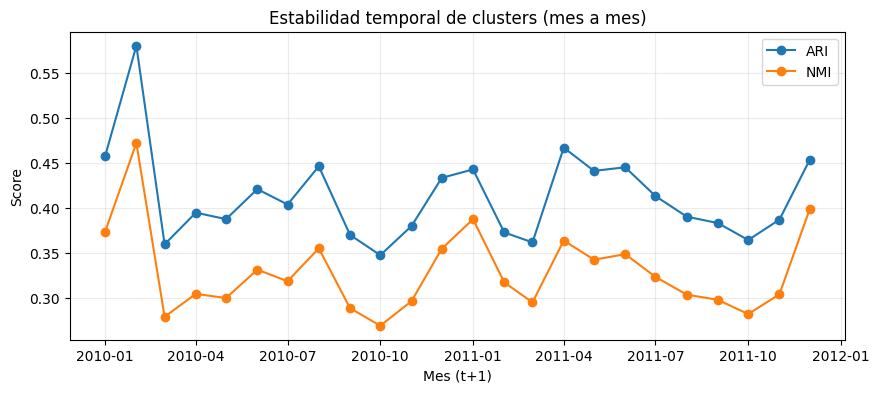

,count,mean,min,25%,50%,75%,max,std
month_t,24,2010-11-15 14:00:00,2009-12-01 00:00:00,2010-05-24 06:00:00,2010-11-16 00:00:00,2011-05-08 18:00:00,2011-11-01 00:00:00,NaN
month_t1,24,2010-12-16 00:00:00,2010-01-01 00:00:00,2010-06-23 12:00:00,2010-12-16 12:00:00,2011-06-08 12:00:00,2011-12-01 00:00:00,NaN
n_common,24.0,1703.375,955.0,1560.0,1644.5,1784.5,2460.0,359.42984
ARI,24.0,0.412648,0.347461,0.378113,0.399273,0.443392,0.580304,0.050516
NMI,24.0,0.329452,0.26907,0.297466,0.31787,0.35475,0.472118,0.046607


In [31]:
# Visual: estabilidad por mes
plt.figure(figsize=(10,4))
plt.plot(stab["month_t1"], stab["ARI"], marker="o", label="ARI")
plt.plot(stab["month_t1"], stab["NMI"], marker="o", label="NMI")
plt.title("Estabilidad temporal de clusters (mes a mes)")
plt.xlabel("Mes (t+1)")
plt.ylabel("Score")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

# Tabla resumen
stab.describe(include="all").T


## 12.2 Drift de centroides por mes (distancia a los centros globales)

Aunque entrenamos un KMeans global (un solo modelo), la **composición** de cada cluster puede cambiar por mes.

Para cada mes y cluster:
- calculamos el centroide empírico (promedio de \(z\)-features)
- medimos su distancia al centro global del KMeans (\(\mu_k\))

Si la distancia crece sostenidamente:
- el cluster “se está moviendo” (posible drift / estacionalidad / cambio de mix)
- alerta para revisión de ventana, features, o re-entrenamiento programado


In [32]:
# Centros globales del KMeans (en espacio escalado)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=z_cols)
centers["cluster_kmeans"] = range(centers.shape[0])

# Centroide empírico por (mes, cluster)
emp = (cm2.groupby(["month","cluster_kmeans"])[z_cols]
       .mean()
       .reset_index())

# Distancia euclidiana a centro global del cluster correspondiente
emp = emp.merge(centers, on="cluster_kmeans", suffixes=("_emp","_global"), how="left")

def row_dist(r):
    v_emp = r[[c+"_emp" for c in z_cols]].values.astype(float)
    v_glb = r[[c+"_global" for c in z_cols]].values.astype(float)
    return float(np.linalg.norm(v_emp - v_glb))

emp["centroid_drift_l2"] = emp.apply(row_dist, axis=1)

emp.head()


,month,cluster_kmeans,z_log_monetary_emp,z_log_ticket_avg_emp,z_log_qty_total_emp,z_log_unique_products_emp,z_log_freq_invoices_emp,z_recency_days_emp,z_log_monetary_global,z_log_ticket_avg_global,z_log_qty_total_global,z_log_unique_products_global,z_log_freq_invoices_global,z_recency_days_global,centroid_drift_l2
0,2009-12-01,0,0.747733,0.759102,0.686410,0.521086,0.278366,-0.729759,0.840989,0.600518,0.790820,0.689478,0.639192,-0.443293,0.534193
1,2009-12-01,1,-0.707499,-0.502058,-0.708858,-0.599180,-0.537018,-0.571956,-0.646926,-0.461945,-0.608334,-0.530377,-0.491695,0.341000,0.925019
2,2010-01-01,0,0.818493,0.638891,0.739770,0.633124,0.543761,-0.582815,0.840989,0.600518,0.790820,0.689478,0.639192,-0.443293,0.190615
3,2010-01-01,1,-0.714985,-0.539381,-0.729677,-0.592894,-0.505941,0.056917,-0.646926,-0.461945,-0.608334,-0.530377,-0.491695,0.341000,0.331915
4,2010-02-01,0,0.876937,0.576356,0.798484,0.739111,0.736343,-0.445790,0.840989,0.600518,0.790820,0.689478,0.639192,-0.443293,0.117655


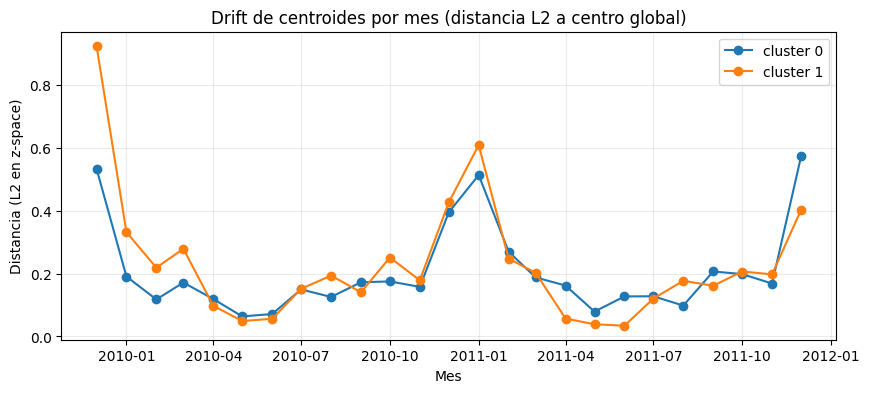

cluster_kmeans,0,1
month,,
2009-12-01,0.534193,0.925019
2010-01-01,0.190615,0.331915
2010-02-01,0.117655,0.218658
2010-03-01,0.171377,0.278711
2010-04-01,0.118954,0.097391


In [33]:
# Visual: drift por cluster
plt.figure(figsize=(10,4))
for k in sorted(emp["cluster_kmeans"].unique()):
    d = emp[emp["cluster_kmeans"]==k].sort_values("month")
    plt.plot(d["month"], d["centroid_drift_l2"], marker="o", label=f"cluster {k}")
plt.title("Drift de centroides por mes (distancia L2 a centro global)")
plt.xlabel("Mes")
plt.ylabel("Distancia (L2 en z-space)")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

emp.pivot_table(index="month", columns="cluster_kmeans", values="centroid_drift_l2").head()


## 12.3 Transiciones mes a mes (matriz + KPIs)

El bloque anterior ya calculó una matriz de transición global. Aquí lo llevamos a un estándar “financiero”:

- **Retención por cluster**: \(P(c_{t+1}=k \mid c_t=k)\)
- **Churn operacional**: clientes que no reaparecen en \(t+1\) (no se puede observar transición)
- **Matrices por mes** (opcional): útil si hay estacionalidad fuerte

Esto permite diseñar acciones:
- campañas de **reactivación** (clientes que migran a “dormidos”)
- up-sell / cross-sell (migran a “alto valor”)
- alertas tempranas (migran a “bajo valor” + recency sube)


In [34]:
# ============================
# Transiciones: métricas clave
# ============================
cm_sorted = cm2.sort_values(["CustomerID","month"]).copy()
cm_sorted["month_next"] = cm_sorted.groupby("CustomerID")["month"].shift(-1)
cm_sorted["cluster_next"] = cm_sorted.groupby("CustomerID")["cluster_kmeans"].shift(-1)

# Definimos transición SOLO si el siguiente registro es el mes inmediato (t -> t+1)
# (Si un cliente desaparece y vuelve después, eso se considera churn + reingreso, no transición 1-step)
month_to_next = {m: months[i+1] for i,m in enumerate(sorted(cm2["month"].unique())[:-1])}
cm_sorted["month_expected_next"] = cm_sorted["month"].map(month_to_next)

one_step = cm_sorted[(cm_sorted["month_next"] == cm_sorted["month_expected_next"])].dropna(subset=["cluster_next"]).copy()
one_step["cluster_next"] = one_step["cluster_next"].astype(int)

# Matriz de transición 1-step (normalizada por fila)
mat_1step = pd.crosstab(one_step["cluster_kmeans"], one_step["cluster_next"], normalize="index")

# Retención por cluster (diagonal)
ret_by_cluster = pd.Series(np.diag(mat_1step.reindex(index=sorted(mat_1step.index), columns=sorted(mat_1step.columns)).fillna(0).values),
                           index=sorted(mat_1step.index),
                           name="retention")

# Churn operacional: clientes con registro en t pero sin registro en t+1 inmediato
has_next_immediate = cm_sorted["month_next"] == cm_sorted["month_expected_next"]
churn_rate = 1 - has_next_immediate.mean()

print("Churn operacional (no aparece en t+1 inmediato):", round(churn_rate, 4))
ret_by_cluster


Churn operacional (no aparece en t+1 inmediato): 0.2002


0    0.790591
1    0.849171
Name: retention, dtype: float64

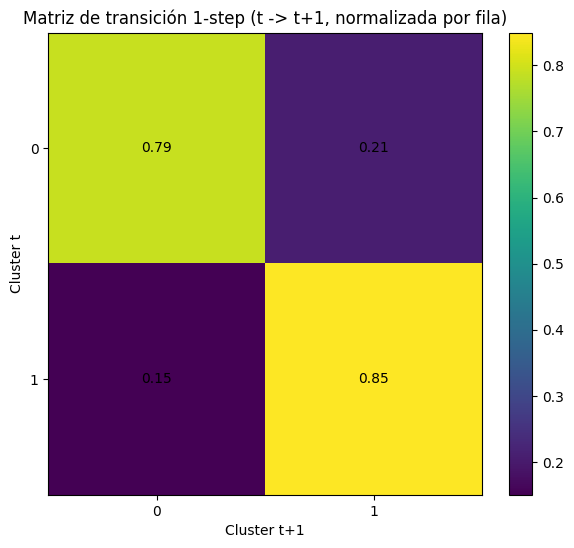

cluster_next,0,1
cluster_kmeans,,
0,0.790591,0.209409
1,0.150829,0.849171


In [35]:
# Visual: matriz 1-step con anotaciones
plt.figure(figsize=(7,6))
plt.imshow(mat_1step.values, aspect="auto")
plt.title("Matriz de transición 1-step (t -> t+1, normalizada por fila)")
plt.xlabel("Cluster t+1")
plt.ylabel("Cluster t")
plt.xticks(range(mat_1step.shape[1]), mat_1step.columns)
plt.yticks(range(mat_1step.shape[0]), mat_1step.index)
plt.colorbar()
for i in range(mat_1step.shape[0]):
    for j in range(mat_1step.shape[1]):
        plt.text(j, i, f"{mat_1step.values[i,j]:.2f}", ha="center", va="center")
plt.show()

mat_1step


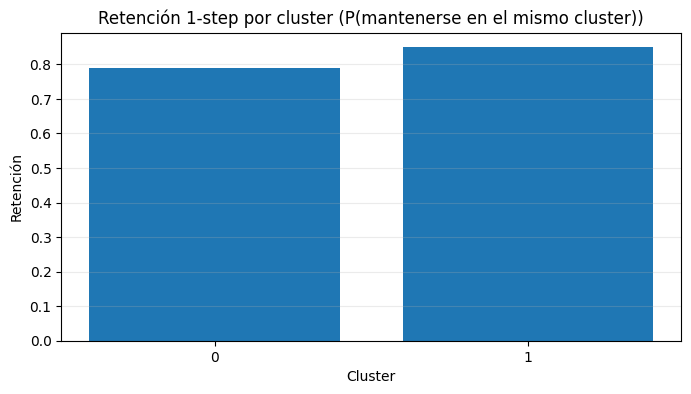

1    0.849171
0    0.790591
Name: retention, dtype: float64

In [36]:
# Visual: retención por cluster
plt.figure(figsize=(8,4))
plt.bar(ret_by_cluster.index.astype(str), ret_by_cluster.values)
plt.title("Retención 1-step por cluster (P(mantenerse en el mismo cluster))")
plt.xlabel("Cluster")
plt.ylabel("Retención")
plt.grid(True, axis="y", alpha=0.25)
plt.show()

ret_by_cluster.sort_values(ascending=False)


## 12.4 Checklist “Industria Financiera” (lo que se exige en producción)

1) **Definición de población** (universo)
- ¿Todos los clientes? ¿Solo activos? ¿Solo con transacciones? ¿Exclusiones?

2) **Corte temporal y no leakage**
- Las features de mes \(t\) deben construirse con info \(\le t\).  
- La ventana rolling debe estar claramente documentada (90 días en este caso).

3) **Trazabilidad**
- Versionar: dataset (hash), features, scaler, modelo, K elegido, random_state.

4) **Monitoreo**
- share de clusters por mes
- estabilidad (ARI/NMI)
- drift de centroides
- métricas de negocio por cluster (cuando existan KPIs)

5) **Accionabilidad**
- cada cluster debe tener: *nombre*, *reglas de negocio*, *tratamiento*, *KPI esperado*.


# Conclusiones Finales — Masterclass de Clustering con Temporalidad

## Estructura de Segmentacion

A traves de K-Means se identificaron dos segmentos principales de clientes:

- Un cluster dominante con mayor concentracion de clientes.
- Un cluster minoritario con comportamiento diferenciado.

La separacion fue validada mediante:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score
- Analisis visual en PCA 2D

Desde el punto de vista matematico, el modelo logra una estructura coherente y consistente.

---

## Interpretacion Temporal

El analisis cliente–mes permitio observar que:

- Las proporciones por cluster son relativamente estables en el tiempo.
- Existen oscilaciones naturales (convergencias y divergencias).
- No se observan colapsos estructurales ni desaparicion de segmentos.

Formalmente, la proporcion por cluster se define como:

$$
Share_{k,t} =
\frac{N_{k,t}}
{\sum_k N_{k,t}}
$$

donde $N_{k,t}$ representa el numero de clientes en el cluster $k$ durante el mes $t$.

La evolucion temporal muestra estabilidad estructural con movilidad interna.

---

## Migracion de Clientes

El analisis de matriz de transicion demostro que:

- Los clientes pueden cambiar de segmento en el tiempo.
- No todos los segmentos son permanentes.
- Existe dinamica conductual real.

Esto confirma que los clusters no son etiquetas fijas, sino representaciones del comportamiento en una ventana temporal.

---

## Implicancias de Negocio

Desde una perspectiva aplicada (retail / banca):

- Los clusters pueden utilizarse como segmentos comerciales.
- Permiten estrategias diferenciadas.
- Facilitan monitoreo de estabilidad y deteccion de drift.
- Pueden integrarse como feature en modelos supervisados posteriores.

La eleccion de \( K \) no es solo estadistica, sino estrategica.

---

## Reflexion Final

El clustering no busca predecir, sino **descubrir estructura latente** en los datos.

Cuando incorporamos temporalidad:

- Pasamos de una segmentacion estatica
- A una segmentacion dinamica y monitoreable

Esto eleva el analisis desde exploratorio a estrategico.

---

## Siguientes Pasos Naturales

- Medir drift mediante PSI mensual.
- Evaluar estabilidad de centroides.
- Integrar clusters en modelos de prediccion.
- Probar ventanas temporales alternativas (30, 90, 180 dias).
- Analizar interpretabilidad avanzada de segmentos.

---

# Cierre

Esta masterclass demostro como construir un pipeline profesional de clustering:

Datos transaccionales → Feature Engineering temporal → Escalamiento → Clustering → Evaluacion → Estabilidad → Interpretacion → Produccion.

El clustering, cuando se implementa correctamente, deja de ser un ejercicio academico y se convierte en una herramienta estrategica de segmentacion.

---

**Autor: Josef Rodriguez**  
Masterclass de Clustering con Temporalidad  
2026